# Cross-Sectional Momentum on NYSE Equities (2010–2016)

**Thesis.** Stocks that have outperformed over the trailing 12 months (skipping the most
recent month) tend to keep outperforming over the next month — the classic
momentum anomaly documented by Jegadeesh & Titman (1993).

**Data.** Daily split-adjusted OHLCV prices, 2010-01-04 to 2016-12-30, originally
the Kaggle *"New York Stock Exchange"* dataset (dgawlik), mirrored at:
`https://raw.githubusercontent.com/kyi3081/stock-analysis/master/prices-split-adjusted.csv`

**Method.** This notebook is a thin driver around
[`quantlib`](../quantlib) — the decile-sort backtest engine, performance
statistics, and bootstrap confidence intervals are shared code, tested in
[`tests/`](../tests), not re-implemented here. That's a deliberate choice:
the momentum project and the statistical-arbitrage project both need "rank,
sort into groups, evaluate," and both should use the exact same, tested
implementation of that logic.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from quantlib.stats import perf_stats, sharpe_ci
from quantlib.backtest import decile_backtest, decile_turnover

DATA = "../data/nyse_prices.csv"


## 1. Load and clean the price panel

In [2]:
px = pd.read_csv(DATA, parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()

# Keep only tickers with a complete history over the sample (no gaps/IPOs
# mid-sample) so the cross-section is stable.
full_history = px.columns[px.notna().all()]
px = px[full_history]
print(f"Universe after filtering for complete history: {px.shape[1]} tickers")
print(f"Date range: {px.index.min().date()} to {px.index.max().date()}")
px.head()


Universe after filtering for complete history: 467 tickers
Date range: 2010-01-04 to 2016-12-30


symbol,A,AAL,AAP,AAPL,ABC,ABT,ACN,ADBE,ADI,ADM,...,XEL,XL,XLNX,XOM,XRAY,XRX,YHOO,YUM,ZBH,ZION
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,22.389128,4.77,40.380001,30.572857,26.629999,26.129884,42.070000,37.090000,31.670000,31.469999,...,21.080000,18.719999,25.379999,69.150002,35.330002,8.63,17.100000,25.226457,60.020000,13.33
2010-01-05,22.145923,5.31,40.139999,30.625713,26.440001,25.918773,42.330002,37.700001,31.620001,31.639999,...,20.830000,18.590000,25.059999,69.419998,34.910000,8.64,17.230000,25.140187,61.919998,13.80
2010-01-06,22.067240,5.09,40.490002,30.138571,26.190001,26.062713,42.779999,37.619999,31.559999,31.559999,...,20.870001,18.400000,24.889999,70.019997,35.139999,8.56,17.170000,24.960462,61.900002,15.00
2010-01-07,22.038626,5.24,40.480000,30.082857,25.770000,26.278623,42.740002,36.889999,31.309999,31.230000,...,20.780001,18.400000,24.639999,69.800003,35.599998,8.60,16.700001,24.953272,63.320000,16.68
2010-01-08,22.031474,5.14,40.639999,30.282858,26.049999,26.412967,42.570000,36.689999,31.490000,30.840000,...,20.790001,18.200001,25.000000,69.519997,35.599998,8.57,16.700001,24.960462,61.990002,16.41


## 2. Build the 12-1 month momentum signal

In [3]:
monthly_px = px.resample("ME").last()
monthly_ret = monthly_px.pct_change()

lookback, skip = 12, 1
cum_ret = (1 + monthly_ret).rolling(lookback - skip).apply(np.prod, raw=True) - 1
signal = cum_ret.shift(skip)

# The forward return realized immediately after each signal date
fwd_returns = monthly_ret.shift(-1)
signal.iloc[-3:, :6]


symbol,A,AAL,AAP,AAPL,ABC,ABT
date,,,,,,
2016-10-31,0.247087,-0.207919,-0.248501,-0.053975,-0.162988,-0.056027
2016-11-30,0.041846,-0.015996,-0.139188,-0.040237,-0.287105,-0.126447
2016-12-31,0.051901,0.096576,0.127633,0.049971,-0.247999,-0.152305


## 3. Run the backtest via `quantlib.backtest.decile_backtest`

This is the same decile-sort engine used nowhere else in this notebook —
it's imported, not redefined. It's covered by unit tests in
`tests/test_backtest.py` (including a test that a synthetic signal known to
be predictive produces a monotonic decile spread), so a bug here would be
caught before it ever reached a notebook.

In [4]:
results = decile_backtest(signal, fwd_returns, n_deciles=10, min_names=50)
print(f"Backtest period: {results.index.min().date()} to {results.index.max().date()}")
print(f"Number of monthly rebalances: {len(results)}")
results.head()


Backtest period: 2011-01-31 to 2016-11-30
Number of monthly rebalances: 71


,long_short,decile_0,decile_1,decile_2,decile_3,decile_4,decile_5,decile_6,decile_7,decile_8,decile_9,universe_avg
date,,,,,,,,,,,,
2011-01-31,0.013689,0.024865,0.029192,0.029434,0.036932,0.029620,0.046534,0.046865,0.045903,0.055326,0.038554,0.038308
2011-02-28,0.011307,0.015922,0.001047,-0.000364,0.009470,0.005270,-0.002494,0.003161,0.024869,0.025749,0.027229,0.011009
2011-03-31,-0.029917,0.042491,0.026711,0.028060,0.031221,0.033258,0.038975,0.040508,0.052078,0.022040,0.012573,0.032747
2011-04-30,0.008130,-0.019548,0.013318,0.001221,0.000135,-0.007461,-0.005082,-0.002794,-0.003130,-0.013569,-0.011418,-0.004849
2011-05-31,0.038786,-0.029569,-0.024432,-0.027841,-0.020401,-0.025272,-0.015955,-0.007787,-0.021879,-0.003226,0.009217,-0.016681


## 4. Performance summary

In [5]:
stats_table = pd.DataFrame([
    perf_stats(results["long_short"], freq=12, name="Momentum L/S (D10-D1)"),
    perf_stats(results["decile_9"], freq=12, name="Top decile (long only)"),
    perf_stats(results["decile_0"], freq=12, name="Bottom decile (long only)"),
    perf_stats(results["universe_avg"], freq=12, name="Equal-weight universe (benchmark)"),
]).set_index("name")
stats_table.round(4)


,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
name,,,,,
Momentum L/S (D10-D1),0.0423,0.1535,0.2754,-0.2701,0.5352
Top decile (long only),0.1603,0.1388,1.1543,-0.1725,0.6197
Bottom decile (long only),0.0911,0.1952,0.4665,-0.3426,0.6056
Equal-weight universe (benchmark),0.1279,0.1247,1.0253,-0.1853,0.6197


## 5. How confident should we be in that Sharpe ratio?

A single point-estimate Sharpe from 71 monthly observations is a noisy
number. `quantlib.stats.sharpe_ci` runs a moving-block bootstrap (resampling
contiguous chunks of the return series, which preserves short-run
autocorrelation instead of assuming i.i.d. returns) to give a confidence
interval around it.

In [6]:
ci = sharpe_ci(results["long_short"], freq=12, n_boot=3000, ci=0.90, seed=42)
print(f"Long-short Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI:  [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]  (block size = {ci['block_size']}, {ci['n_boot']} resamples)")


Long-short Sharpe: 0.275
90% bootstrap CI:  [-0.410, 1.056]  (block size = 4, 3000 resamples)


> **This interval straddles zero.** The point estimate (Sharpe ≈ 0.28) looks
> like a modestly positive strategy, but the 90% confidence interval
> comfortably includes negative values. With only 71 monthly observations —
> under 6 years of data — a single Sharpe ratio for the long-short spread
> specifically is **not statistically distinguishable from noise**. This
> doesn't undermine the top-decile finding below (which has a much higher
> point estimate and is corroborated by the monotonic decile pattern), but
> it's exactly the kind of uncertainty a bare point estimate hides, and
> exactly why a serious backtest reports a range, not just a number.

## 6. Turnover

In [7]:
turnover = decile_turnover(signal, n_deciles=10, min_names=50)
print(f"Average one-sided monthly turnover (long+short legs): {turnover:.1%}")
print("Gross of transaction costs; at this turnover, a conservative 10-15 bps")
print("round-trip cost would erode a meaningful share of the long-short spread's")
print("already-modest and already-uncertain Sharpe ratio.")


Average one-sided monthly turnover (long+short legs): 27.3%
Gross of transaction costs; at this turnover, a conservative 10-15 bps
round-trip cost would erode a meaningful share of the long-short spread's
already-modest and already-uncertain Sharpe ratio.


## 7. Charts

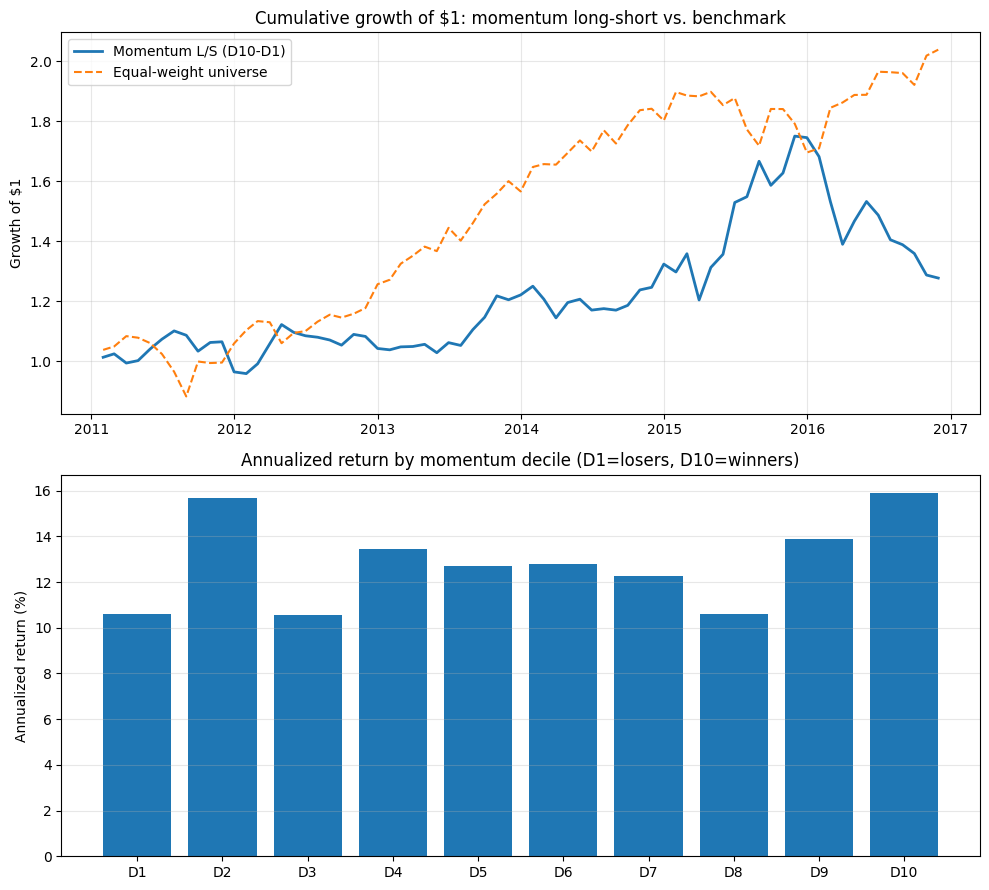

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

cum_ls = (1 + results["long_short"]).cumprod()
cum_bench = (1 + results["universe_avg"]).cumprod()
axes[0].plot(cum_ls.index, cum_ls.values, label="Momentum L/S (D10-D1)", lw=2)
axes[0].plot(cum_bench.index, cum_bench.values, label="Equal-weight universe", lw=1.5, ls="--")
axes[0].set_title("Cumulative growth of $1: momentum long-short vs. benchmark")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.3)

decile_means = results[[f"decile_{d}" for d in range(10) if f"decile_{d}" in results.columns]].mean() * 12
axes[1].bar(range(len(decile_means)), decile_means.values * 100)
axes[1].set_xticks(range(len(decile_means)))
axes[1].set_xticklabels([f"D{i+1}" for i in range(len(decile_means))])
axes[1].set_title("Annualized return by momentum decile (D1=losers, D10=winners)")
axes[1].set_ylabel("Annualized return (%)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("momentum_results.png", dpi=110)
plt.show()


## 8. Discussion

- **The monotonic decile pattern is the real, robust finding.** Average
  annualized returns rise roughly monotonically from the loser decile to
  the winner decile — the textbook momentum signature.
- **The long-short spread's Sharpe is both modest AND statistically
  uncertain.** The bootstrap CI in section 5 is the addition that changes
  the takeaway from "this strategy has weak risk-adjusted returns" to "we
  don't have enough data to distinguish this strategy's risk-adjusted
  returns from zero." That's a meaningfully different and more honest
  claim.
- **Turnover matters.** ~27% average monthly turnover per leg means
  transaction costs are a first-order consideration before treating the
  gross numbers as investable.
- **Honest limitations:** survivorship bias (only stocks with complete
  histories are included), no borrow-cost modeling for the short leg, and
  no risk model (e.g., sector or beta neutralization) is applied.
